# Noise2Noise for Astrophotography Denoising

Train a U-Net to denoise galaxy images **without clean ground truth**, following Lehtinen et al. (2018), *Noise2Noise: Learning Image Restoration without Clean Data* ([arXiv:1803.04189](https://arxiv.org/abs/1803.04189)).

**Key idea.** If we have two independent noisy observations of the same scene, training a network to map one to the other minimizes the same expected loss as training against clean targets — provided the noise is zero-mean. This perfectly matches the astrophotography setting where multiple noisy exposures of a galaxy are easy, but clean references don't exist.

**Setup**
- **Dataset**: Galaxy10 DECaLS (~17k labeled galaxy images, 256×256 RGB)
- **Noise model**: synthetic Gaussian + Poisson, fresh noise sample per epoch → independent pairs
- **Model**: U-Net (encoder-decoder with skip connections, ~7.7M params at `base=32`)
- **Loss**: L2 (matches the N2N theoretical guarantee for Gaussian noise; L1 also works)
- **Runtime**: Colab free-tier friendly — 128×128 random crops, small batch, mixed precision on GPU

Open in Colab → Runtime → Change runtime type → **GPU (T4)**.

## 1. Setup

In [1]:
!pip install -q astroNN h5py

import os, math, time, random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)
if DEVICE == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 37.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 73.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 40.4 MB/s eta 0:00:00
Device: cuda
GPU: Tesla T4


## 2. Configuration

In [2]:
class CFG:
    # Data
    n_images   = 4000     # subset for fast iteration (full set: ~17k)
    crop_size  = 128      # random crop fed to the network
    val_frac   = 0.1

    # Noise (applied independently to each member of a pair)
    gauss_sigma = 25/255  # additive Gaussian std in [0,1] units
    poisson_lam = 30.0    # photon counts scale (lower = noisier)

    # Model
    base_filters = 32     # 32 fits Colab T4 comfortably; 64 = paper-size
    depth        = 4

    # Training
    batch_size = 16
    epochs     = 20
    lr         = 1e-3
    num_workers = 2

cfg = CFG()

## 3. Dataset — Galaxy10 DECaLS

We use Galaxy10 DECaLS (17,736 labeled galaxy images). The images are already reasonably clean → we treat them as our latent *signal* and synthesize two independent noisy versions on the fly. This is the experimental setup from §3 of the N2N paper.

In [3]:
from astroNN.datasets import load_galaxy10

images, _labels = load_galaxy10()   # uint8, (N, 256, 256, 3)
print('Loaded:', images.shape, images.dtype)

# Subsample + convert to float32 in [0,1]
idx = np.random.RandomState(SEED).permutation(len(images))[:cfg.n_images]
images = images[idx].astype(np.float32) / 255.0
print('Subset:', images.shape)

Galaxy10_DECals.h5: 100%|█████████▉| 2.73G/2.74G [00:52<00:00, 53.8MB/s]

Downloaded Galaxy10 successfully to /root/.astroNN/datasets/Galaxy10_DECals.h5


Galaxy10_DECals.h5: 2.74GB [01:01, 44.2MB/s]                            


Loaded: (17736, 256, 256, 3) uint8
Subset: (4000, 256, 256, 3)


In [4]:
def add_noise(x: torch.Tensor) -> torch.Tensor:
    """Mixed Poisson-Gaussian noise. Zero-mean as required by N2N theory."""
    # Shot noise: ~Poisson(lam*x)/lam, approximated as Gaussian for differentiability
    shot = torch.randn_like(x) * torch.sqrt(torch.clamp(x, min=0) / cfg.poisson_lam)
    # Read noise
    read = torch.randn_like(x) * cfg.gauss_sigma
    return torch.clamp(x + shot + read, 0.0, 1.0)


class Galaxy10N2N(Dataset):
    """Returns (noisy_input, noisy_target, clean) where the two noisy views
    are independent noise realizations of the same underlying image.
    `clean` is only used for monitoring — never seen by the loss."""

    def __init__(self, images: np.ndarray, crop: int, train: bool = True):
        self.images = images
        self.crop = crop
        self.train = train

    def __len__(self):
        return len(self.images)

    def __getitem__(self, i):
        img = self.images[i]                          # H, W, 3
        H, W, _ = img.shape
        c = self.crop
        if self.train:
            y = random.randint(0, H - c); x = random.randint(0, W - c)
        else:
            y = (H - c) // 2; x = (W - c) // 2
        patch = img[y:y+c, x:x+c]                     # H, W, 3
        patch = torch.from_numpy(patch).permute(2, 0, 1).contiguous()  # 3, H, W

        if self.train and random.random() < 0.5:
            patch = torch.flip(patch, dims=[-1])

        noisy_in  = add_noise(patch)
        noisy_tgt = add_noise(patch)                   # independent draw
        return noisy_in, noisy_tgt, patch


n_val = int(len(images) * cfg.val_frac)
train_imgs, val_imgs = images[n_val:], images[:n_val]
train_ds = Galaxy10N2N(train_imgs, cfg.crop_size, train=True)
val_ds   = Galaxy10N2N(val_imgs,   cfg.crop_size, train=False)

train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True,
                          num_workers=cfg.num_workers, pin_memory=(DEVICE=='cuda'))
val_loader   = DataLoader(val_ds,   batch_size=cfg.batch_size, shuffle=False,
                          num_workers=cfg.num_workers, pin_memory=(DEVICE=='cuda'))

print(f'Train: {len(train_ds)} | Val: {len(val_ds)}')

Train: 3600 | Val: 400


### Sanity check — visualize a noisy pair

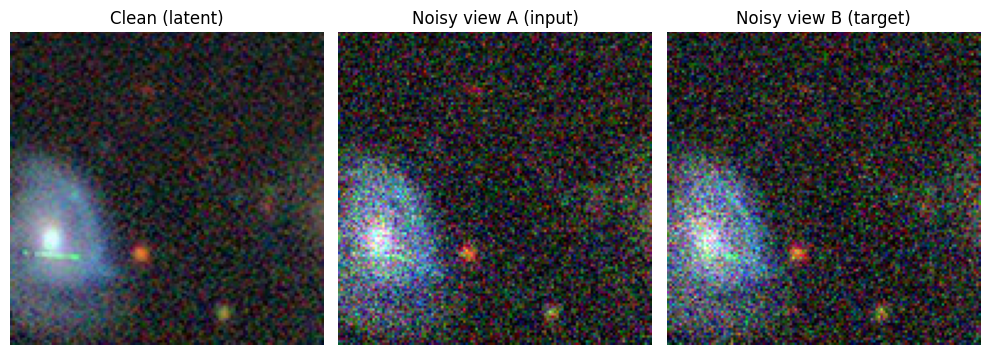

In [5]:
noisy_a, noisy_b, clean = next(iter(train_loader))

def show(t):
    return t.permute(1, 2, 0).clamp(0, 1).cpu().numpy()

fig, axes = plt.subplots(1, 3, figsize=(10, 4))
axes[0].imshow(show(clean[0]));   axes[0].set_title('Clean (latent)')
axes[1].imshow(show(noisy_a[0])); axes[1].set_title('Noisy view A (input)')
axes[2].imshow(show(noisy_b[0])); axes[2].set_title('Noisy view B (target)')
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()

## 4. Model — U-Net

Standard encoder-decoder with skip connections. Outputs the denoised image directly (no residual), passed through `sigmoid` to stay in [0, 1].

In [6]:
class DoubleConv(nn.Module):
    def __init__(self, c_in, c_out):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(c_in, c_out, 3, padding=1, bias=False),
            nn.BatchNorm2d(c_out), nn.ReLU(inplace=True),
            nn.Conv2d(c_out, c_out, 3, padding=1, bias=False),
            nn.BatchNorm2d(c_out), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.net(x)


class UNet(nn.Module):
    def __init__(self, in_ch=3, out_ch=3, base=32, depth=4):
        super().__init__()
        self.depth = depth
        self.encs = nn.ModuleList(); self.pools = nn.ModuleList()
        ch = in_ch
        for i in range(depth):
            o = base * (2 ** i)
            self.encs.append(DoubleConv(ch, o))
            self.pools.append(nn.MaxPool2d(2))
            ch = o
        self.bottleneck = DoubleConv(ch, base * (2 ** depth))
        ch = base * (2 ** depth)
        self.ups = nn.ModuleList(); self.decs = nn.ModuleList()
        for i in reversed(range(depth)):
            skip = base * (2 ** i)
            self.ups.append(nn.ConvTranspose2d(ch, skip, 2, 2))
            self.decs.append(DoubleConv(skip * 2, skip))
            ch = skip
        self.head = nn.Conv2d(ch, out_ch, 1)

    def forward(self, x):
        skips = []
        for e, p in zip(self.encs, self.pools):
            x = e(x); skips.append(x); x = p(x)
        x = self.bottleneck(x)
        for u, d, s in zip(self.ups, self.decs, reversed(skips)):
            x = u(x)
            if x.shape[-2:] != s.shape[-2:]:
                x = F.interpolate(x, size=s.shape[-2:], mode='bilinear', align_corners=False)
            x = d(torch.cat([s, x], dim=1))
        return torch.sigmoid(self.head(x))


model = UNet(base=cfg.base_filters, depth=cfg.depth).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f'U-Net parameters: {n_params/1e6:.2f}M')

U-Net parameters: 7.76M


## 5. Metrics

In [7]:
def psnr(pred: torch.Tensor, target: torch.Tensor) -> float:
    mse = F.mse_loss(pred.clamp(0, 1), target).item()
    return 99.0 if mse == 0 else 10 * math.log10(1.0 / mse)

## 6. Training

The loss is computed between the network output (on `noisy_in`) and `noisy_tgt`. The clean image is *never* used for training — only for diagnostic PSNR.

In [8]:
opt = torch.optim.Adam(model.parameters(), lr=cfg.lr)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=cfg.epochs)
scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE=='cuda'))

history = {'train_loss': [], 'val_loss': [], 'val_psnr_noisy': [], 'val_psnr_clean': []}

for epoch in range(1, cfg.epochs + 1):
    # --- train ---
    model.train(); t0 = time.time(); train_loss = 0.0
    for noisy_in, noisy_tgt, _ in train_loader:
        noisy_in  = noisy_in.to(DEVICE, non_blocking=True)
        noisy_tgt = noisy_tgt.to(DEVICE, non_blocking=True)
        opt.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=(DEVICE=='cuda')):
            pred = model(noisy_in)
            loss = F.mse_loss(pred, noisy_tgt)
        scaler.scale(loss).backward()
        scaler.step(opt); scaler.update()
        train_loss += loss.item() * noisy_in.size(0)
    train_loss /= len(train_ds)

    # --- validate ---
    model.eval(); val_loss = 0.0; val_psnr_noisy = 0.0; val_psnr_clean = 0.0; n = 0
    with torch.no_grad():
        for noisy_in, noisy_tgt, clean in val_loader:
            noisy_in  = noisy_in.to(DEVICE); noisy_tgt = noisy_tgt.to(DEVICE); clean = clean.to(DEVICE)
            pred = model(noisy_in)
            val_loss += F.mse_loss(pred, noisy_tgt).item() * noisy_in.size(0)
            val_psnr_noisy += psnr(noisy_in, clean) * noisy_in.size(0)  # baseline
            val_psnr_clean += psnr(pred, clean)     * noisy_in.size(0)  # diagnostic
            n += noisy_in.size(0)
    val_loss /= n; val_psnr_noisy /= n; val_psnr_clean /= n
    sched.step()

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_psnr_noisy'].append(val_psnr_noisy)
    history['val_psnr_clean'].append(val_psnr_clean)

    print(f'[{epoch:02d}/{cfg.epochs}] train {train_loss:.4f} | val {val_loss:.4f} '
          f'| PSNR noisy {val_psnr_noisy:5.2f} → denoised {val_psnr_clean:5.2f} dB '
          f'| {time.time()-t0:.0f}s')

/tmp/ipykernel_4159/1494593173.py:3: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
/tmp/ipykernel_4159/1494593173.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


[01/20] train 0.0295 | val 0.0170 | PSNR noisy 18.22 → denoised 25.76 dB | 19s
[02/20] train 0.0160 | val 0.0168 | PSNR noisy 18.22 → denoised 26.44 dB | 16s
[03/20] train 0.0159 | val 0.0167 | PSNR noisy 18.22 → denoised 26.46 dB | 17s
[04/20] train 0.0158 | val 0.0168 | PSNR noisy 18.22 → denoised 26.21 dB | 23s
[05/20] train 0.0158 | val 0.0167 | PSNR noisy 18.22 → denoised 26.46 dB | 18s
[06/20] train 0.0157 | val 0.0168 | PSNR noisy 18.22 → denoised 26.19 dB | 16s
[07/20] train 0.0156 | val 0.0167 | PSNR noisy 18.22 → denoised 26.58 dB | 16s
[08/20] train 0.0156 | val 0.0167 | PSNR noisy 18.22 → denoised 26.55 dB | 16s
[09/20] train 0.0156 | val 0.0166 | PSNR noisy 18.22 → denoised 26.71 dB | 16s
[10/20] train 0.0157 | val 0.0166 | PSNR noisy 18.22 → denoised 26.67 dB | 17s
[11/20] train 0.0156 | val 0.0166 | PSNR noisy 18.22 → denoised 26.71 dB | 17s
[12/20] train 0.0156 | val 0.0166 | PSNR noisy 18.22 → denoised 26.72 dB | 17s
[13/20] train 0.0156 | val 0.0166 | PSNR noisy 18.22

## 7. Curves

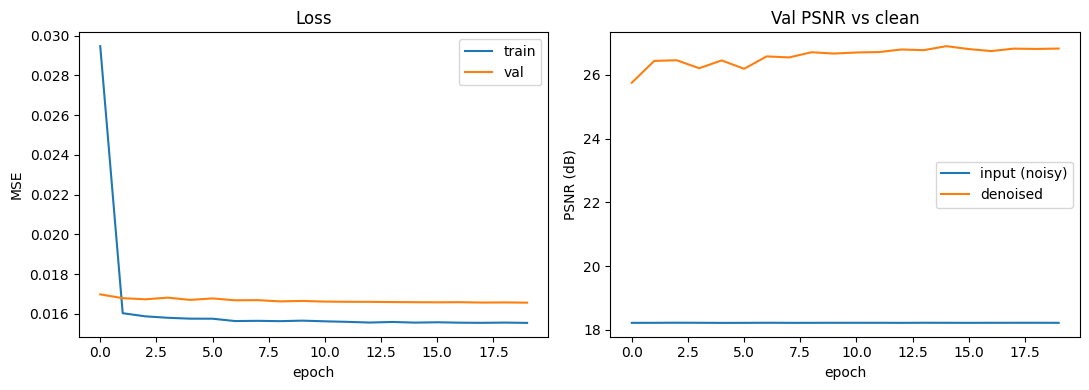

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history['train_loss'], label='train')
axes[0].plot(history['val_loss'], label='val')
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('MSE'); axes[0].set_title('Loss'); axes[0].legend()
axes[1].plot(history['val_psnr_noisy'], label='input (noisy)')
axes[1].plot(history['val_psnr_clean'], label='denoised')
axes[1].set_xlabel('epoch'); axes[1].set_ylabel('PSNR (dB)'); axes[1].set_title('Val PSNR vs clean'); axes[1].legend()
plt.tight_layout(); plt.show()

## 8. Qualitative results

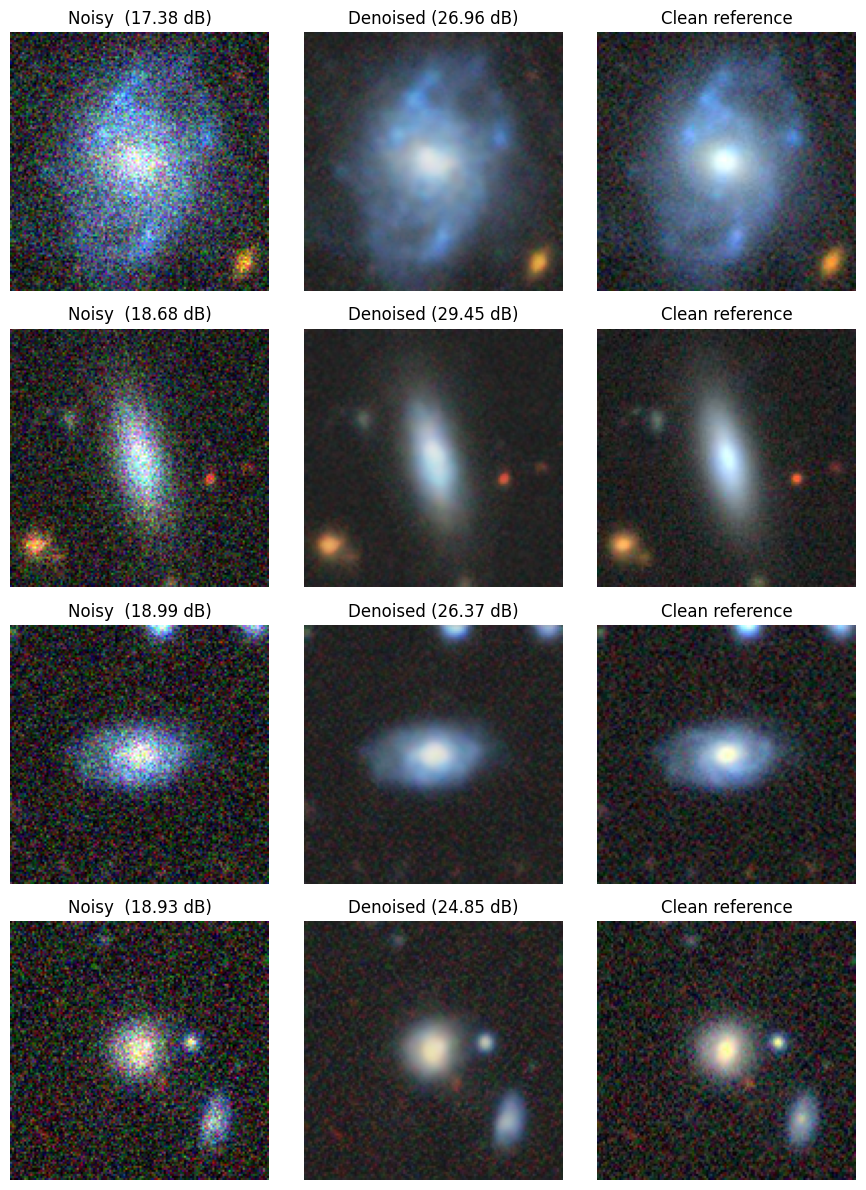

In [10]:
model.eval()
noisy_in, _, clean = next(iter(val_loader))
with torch.no_grad():
    pred = model(noisy_in.to(DEVICE)).cpu()

k = min(4, noisy_in.size(0))
fig, axes = plt.subplots(k, 3, figsize=(9, 3*k))
if k == 1: axes = axes[None, :]
for i in range(k):
    axes[i,0].imshow(show(noisy_in[i])); axes[i,0].set_title(f'Noisy  ({psnr(noisy_in[i], clean[i]):.2f} dB)')
    axes[i,1].imshow(show(pred[i]));     axes[i,1].set_title(f'Denoised ({psnr(pred[i], clean[i]):.2f} dB)')
    axes[i,2].imshow(show(clean[i]));    axes[i,2].set_title('Clean reference')
    for ax in axes[i]: ax.axis('off')
plt.tight_layout(); plt.show()

## 9. Save weights

In [11]:
out = Path('unet_n2n_galaxy10.pt')
torch.save({'model': model.state_dict(), 'cfg': vars(cfg), 'history': history}, out)
print('Saved →', out.resolve())

# In Colab, download with:
# from google.colab import files; files.download(str(out))

Saved → /content/unet_n2n_galaxy10.pt


## 10. Try it on your own astrophoto

Upload any image (PNG / JPEG / TIFF). The model expects RGB in [0, 1]; it will be tiled if larger than ~1k px to keep VRAM bounded.

**Honest expectations.** The model was trained on Galaxy10 DECaLS with synthetic Poisson+Gaussian noise. On real amateur astrophotos it will:
- Work reasonably well on **single-galaxy subjects** with similar color stretch.
- Over-smooth **star fields and thin filaments** (it has never seen them).
- Possibly amplify or learn-around **hot pixels, amp glow, JPEG blocks** — those violate the zero-mean noise assumption.

If results look bad, that's expected — it's the natural lead-in to the "fine-tune on real pairs" next step.

Saving M101.jpg to M101 (1).jpg
Input shape: (3, 4168, 3840)


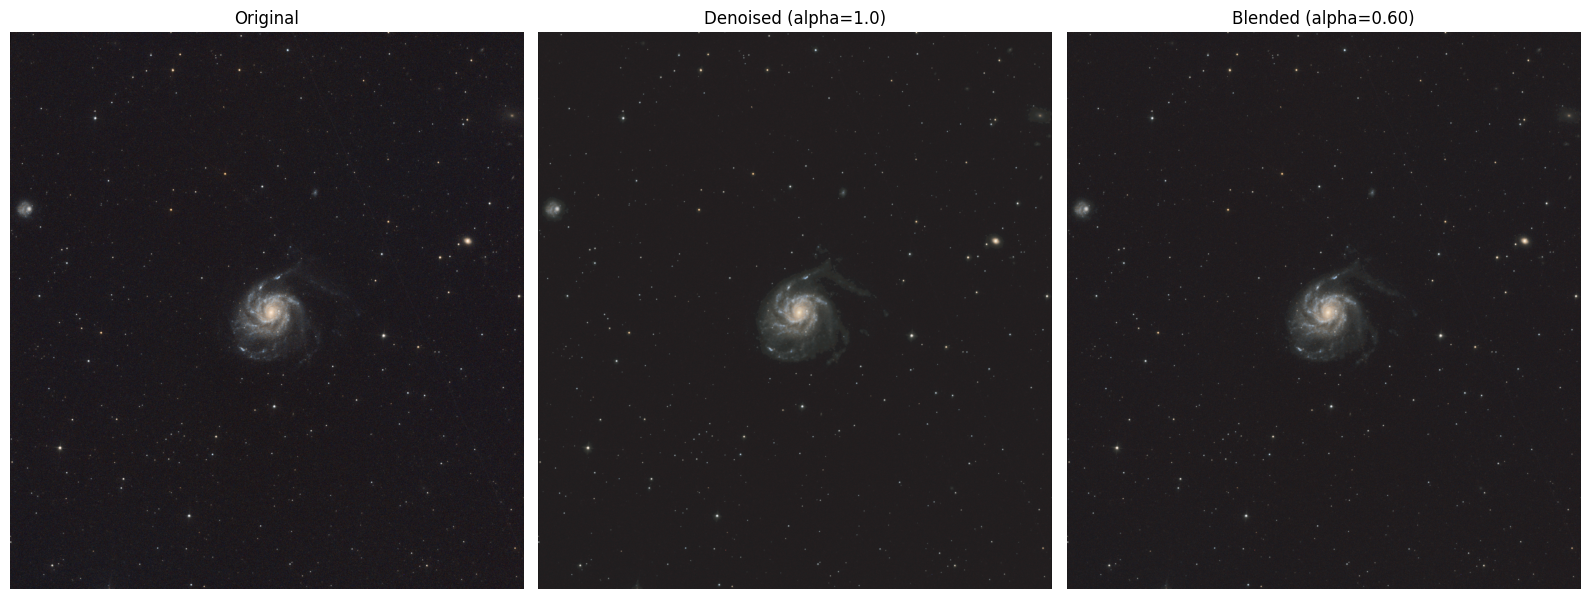

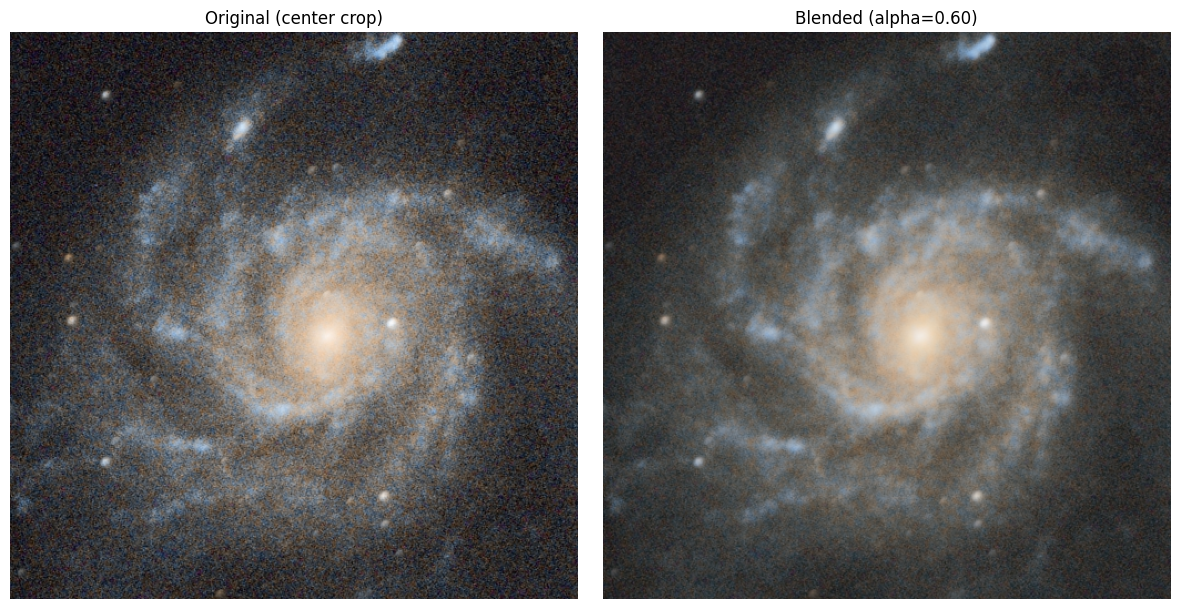

Saved -> /content/M101 (1)_denoised_a0.60.png


In [15]:
# --- Colab: upload an image ---
from google.colab import files
uploaded = files.upload()
image_path = next(iter(uploaded))

# --- Aggressiveness knob ---
# 1.0 = full model output (may over-smooth on out-of-domain images)
# 0.0 = no denoising (just the original)
# 0.5-0.7 is a good starting point for real astrophotos
alpha = 0.6

from PIL import Image

def load_image(path: str) -> torch.Tensor:
    img = Image.open(path).convert('RGB')
    arr = np.asarray(img, dtype=np.float32) / 255.0     # H, W, 3
    return torch.from_numpy(arr).permute(2, 0, 1)        # 3, H, W


@torch.no_grad()
def denoise_tiled(model, img: torch.Tensor, tile: int = 256, overlap: int = 32) -> torch.Tensor:
    """Run model on arbitrarily large images by tiling with overlap blending."""
    model.eval()
    C, H, W = img.shape
    stride = tile - overlap
    pad_h = (16 - H % 16) % 16
    pad_w = (16 - W % 16) % 16
    img_p = F.pad(img.unsqueeze(0), (0, pad_w, 0, pad_h), mode='reflect').squeeze(0)
    Hp, Wp = img_p.shape[-2:]

    out    = torch.zeros_like(img_p)
    weight = torch.zeros_like(img_p)
    ramp = torch.ones(tile)
    if overlap > 0:
        r = torch.linspace(0, 1, overlap)
        ramp[:overlap] = r; ramp[-overlap:] = r.flip(0)
    win = ramp[:, None] * ramp[None, :]

    ys = list(range(0, max(1, Hp - tile + 1), stride))
    xs = list(range(0, max(1, Wp - tile + 1), stride))
    if ys[-1] + tile < Hp: ys.append(Hp - tile)
    if xs[-1] + tile < Wp: xs.append(Wp - tile)

    for y in ys:
        for x in xs:
            patch = img_p[:, y:y+tile, x:x+tile].unsqueeze(0).to(DEVICE)
            pred = model(patch).squeeze(0).cpu()
            out[:,    y:y+tile, x:x+tile] += pred * win
            weight[:, y:y+tile, x:x+tile] += win

    out = out / weight.clamp(min=1e-8)
    return out[:, :H, :W]


img = load_image(image_path)
print('Input shape:', tuple(img.shape))

denoised_full = denoise_tiled(model, img, tile=256, overlap=32)
denoised = (alpha * denoised_full + (1 - alpha) * img).clamp(0, 1)

# --- Compare original / full denoise / blended ---
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
axes[0].imshow(show(img));            axes[0].set_title('Original')
axes[1].imshow(show(denoised_full));  axes[1].set_title('Denoised (alpha=1.0)')
axes[2].imshow(show(denoised));       axes[2].set_title(f'Blended (alpha={alpha:.2f})')
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()

# --- Side-by-side crop to inspect detail (center 512x512) ---
C, H, W = img.shape
ch, cw = min(512, H), min(512, W)
y0, x0 = (H - ch) // 2, (W - cw) // 2
crop = lambda t: t[:, y0:y0+ch, x0:x0+cw]
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(show(crop(img)));      axes[0].set_title('Original (center crop)')
axes[1].imshow(show(crop(denoised))); axes[1].set_title(f'Blended (alpha={alpha:.2f})')
for ax in axes: ax.axis('off')
plt.tight_layout(); plt.show()

# Save the result
out_path = Path(image_path).with_name(f'{Path(image_path).stem}_denoised_a{alpha:.2f}.png')
Image.fromarray((show(denoised) * 255).clip(0, 255).astype(np.uint8)).save(out_path)
print('Saved ->', out_path.resolve())